In [7]:
import pandas as pd
import numpy as np
import joblib
import time
import tracemalloc
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, accuracy_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)

In [8]:
df = pd.read_csv('../Data/group5-adult.csv')

# Load shared splits

In [9]:
X_train, X_test, y_train, y_test = joblib.load('data/train_test_split.pkl')
preprocessor = joblib.load('data/preprocessor.pkl')

print("Shared data loaded!")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

Shared data loaded!
X_train shape : (23508, 14)
X_test shape  : (5877, 14)


# Full pipeline with LR

In [10]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

print("Logistic Regression pipeline built!")
print(lr_pipeline)


Logistic Regression pipeline built!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                     

 # Track runtime & memory

In [11]:
tracemalloc.start()
start_time = time.time()

lr_pipeline.fit(X_train, y_train)

train_time = time.time() - start_time
current, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Model trained!")
print(f"Training time : {train_time:.4f} seconds")
print(f"Peak memory   : {peak_mem / 1024:.2f} KB")

Model trained!
Training time : 0.2711 seconds
Peak memory   : 39416.78 KB


# Prediction

In [12]:
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"Predictions shape : {y_pred.shape}")
print(f"Sample predictions: {y_pred[:10]}")

Predictions shape : (5877,)
Sample predictions: [1 1 1 1 0 0 0 0 0 0]


# Classification Report

In [13]:
print("=" * 55)
print("LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=['<=50K (0)', '>50K (1)']))
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Train Time: {train_time:.4f}s")
print(f"Peak Mem  : {peak_mem / 1024:.2f} KB")
print("=" * 55)

LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

   <=50K (0)       0.94      0.80      0.86      4466
    >50K (1)       0.57      0.85      0.68      1411

    accuracy                           0.81      5877
   macro avg       0.76      0.82      0.77      5877
weighted avg       0.85      0.81      0.82      5877

Accuracy  : 0.8096
ROC-AUC   : 0.9062
Train Time: 0.2711s
Peak Mem  : 39416.78 KB


# Confusion Matrix Plot

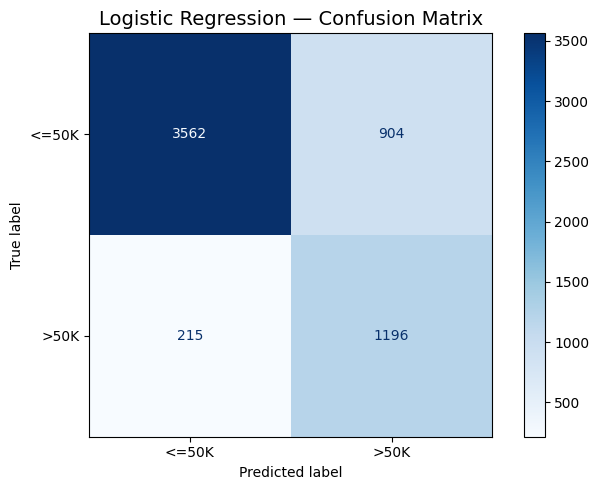

Confusion matrix saved!


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(
    lr_pipeline, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('data/lr_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

# ROC Curve Plot

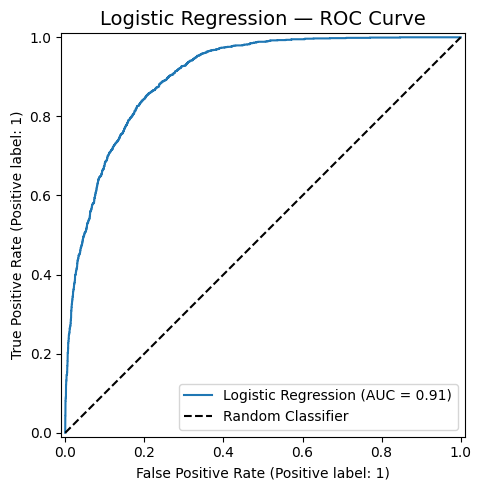

ROC curve saved!


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    lr_pipeline, X_test, y_test,
    ax=ax, name='Logistic Regression'
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('Logistic Regression — ROC Curve', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('data/lr_roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved!")

#  Feature Importance

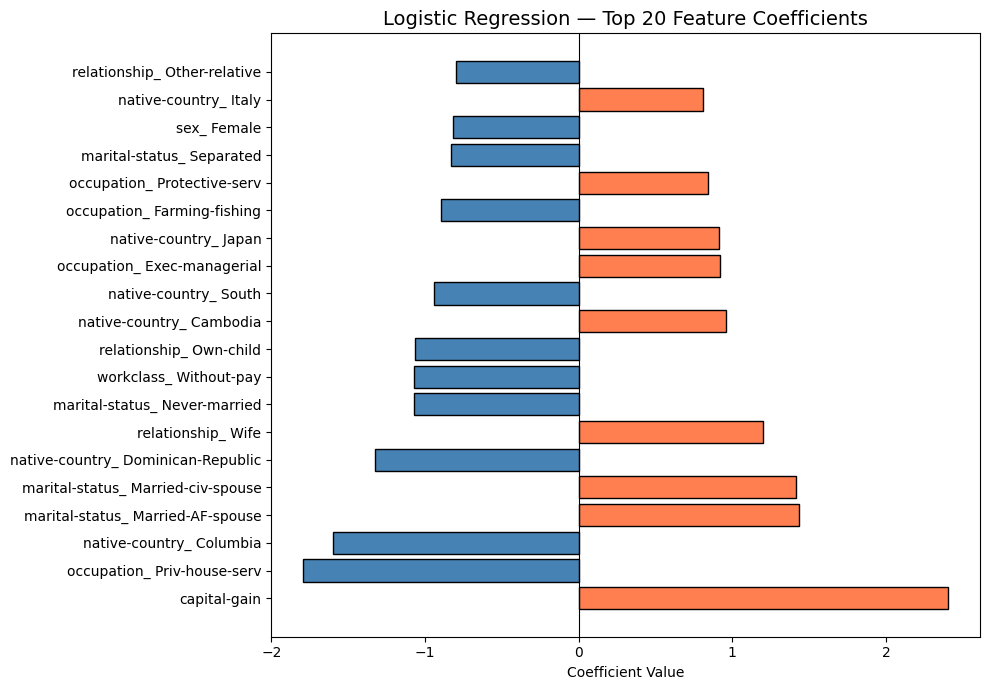

Feature importance saved!


In [16]:
# Get feature names after encoding
feature_names = (
    preprocessor.transformers_[0][2] +  # numeric cols
    list(preprocessor.named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(preprocessor.transformers_[1][2]))
)

coefficients = lr_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 7))
top20 = coef_df.head(20)
colors = ['coral' if c > 0 else 'steelblue' for c in top20['Coefficient']]
ax.barh(top20['Feature'], top20['Coefficient'], color=colors, edgecolor='black')
ax.set_title('Logistic Regression — Top 20 Feature Coefficients', fontsize=14)
ax.set_xlabel('Coefficient Value')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('data/lr_feature_importance.png', dpi=150)
plt.show()
print("Feature importance saved!")

#  Save Model

In [17]:
joblib.dump(lr_pipeline, 'data/lr_model.pkl')
print("Model saved to data/lr_model.pkl")

Model saved to data/lr_model.pkl


# Runtime & Memory Summary

In [18]:
print("=" * 55)
print("⚡ RUNTIME & MEMORY PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Model         : Logistic Regression")
print(f"Training Time : {train_time:.4f} seconds")
print(f"Peak Memory   : {peak_mem / 1024:.2f} KB")
print(f"Prediction Time: ", end="")

start_pred = time.time()
_ = lr_pipeline.predict(X_test)
pred_time = time.time() - start_pred
print(f"{pred_time:.4f} seconds")

print("=" * 55)
print("   Logistic Regression is fast & memory efficient —")
print("   ideal baseline for comparison with other models.")
print("=" * 55)

⚡ RUNTIME & MEMORY PERFORMANCE SUMMARY
Model         : Logistic Regression
Training Time : 0.2711 seconds
Peak Memory   : 39416.78 KB
Prediction Time: 0.0091 seconds
   Logistic Regression is fast & memory efficient —
   ideal baseline for comparison with other models.


In [19]:
lr_results = {
    'model_name'  : 'Logistic Regression',
    'accuracy'    : round(accuracy_score(y_test, y_pred), 4),
    'roc_auc'     : round(roc_auc_score(y_test, y_prob), 4),
    'train_time'  : round(train_time, 4),
    'peak_mem_kb' : round(peak_mem / 1024, 2),
    'pred_time'   : round(pred_time, 4)
}

joblib.dump(lr_results, 'data/lr_results.pkl')
print("Results saved to data/lr_results.pkl")
print(lr_results)

Results saved to data/lr_results.pkl
{'model_name': 'Logistic Regression', 'accuracy': 0.8096, 'roc_auc': 0.9062, 'train_time': 0.2711, 'peak_mem_kb': 39416.78, 'pred_time': 0.0091}
